In [2]:
import math 
import numpy as np
import matplotlib.pyplot as plt
%pip install graphviz
%matplotlib inline


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [8]:
a = 2.0 
b = -3.0 
c = 10.0 
d = a * b + c 
print(d)

4.0


In [9]:
h = 0.001 

# inputs 

a = 2.0 
b = -3.0 
c = 10.0 
d1 = a * b + c 

c += h 
d2 = a * b + c

print("d1",d1)
print("d2",d2)
print("slope : ",(d2 - d1)/ h)


d1 4.0
d2 4.0009999999999994
slope :  0.9999999999994458


In [57]:
class Value:
    def __init__(self,data,_children=(),_op="",label=""):
        self.data = data
        self._prev = set(_children)
        self._op = _op 
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        out = Value(self.data + other.data,(self,other),"+")

        # perform backpropagation on the output of this addition operation
        def _backward():
            self.grad = 1.0 * out.grad 
            other.grad = 1.0 * out.grad

        out._backward = _backward

        return out
    
    def __mul__(self,other):
        out = Value(self.data * other.data,(self,other),"*")

        def _backward():
            self.grad = other.data * out.grad 
            other.grad = self.data * out.grad
        out._backward = _backward

        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t,(self,),"tanh")

        def _backward():
            self.grad = (1 - t ** 2) * out.grad
        out._backward = _backward
        
        return out

a = Value(2.0,label="a")
b = Value(-3.0,label="b")
c = Value(10.0,label="c")

e = a * b; e.label = "e"

d = e + c; d.label = "d"

f = Value(-2.0,label="f")
L = d * f 
L.label = "L"

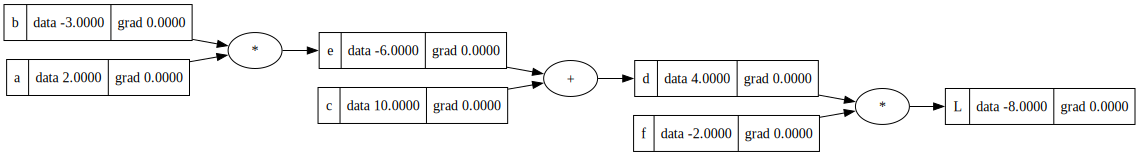

In [26]:
draw_dot(L)

In [27]:
L.grad = 1.0 

d.grad = -2.0 
f.grad = 4.0 

c.grad = -2.0 
e.grad = -2.0

a.grad = -2.0 * b.data 
b.grad = -2.0 * a.data 

In [ ]:
# dd / dc = 1.0 
# dd / de = 1.0 

# WANT : dL / dc = dL / dd * dd / dc = -2.0 * 1.0 = -2.0

# KNOW: 
    # dd / dc = 1.0 
    # dd / de = 1.0
    # dL / dd = -2.0 

#(((c.data + e.data) + h) - (c.data + e.data)) / h


# WANT: dL / db  or dL / da

# KNOW:
    # dL / dd = -2.0
    # dd / de = 1.0


# Chain Rule : dL / db = (dL / de) * -3 



1.000000000000334

In [28]:
def lol():

    h = 0.01 

    a = Value(2.0,label="a")
    b = Value(-3.0,label="b")
    c = Value(10.0,label="c")
    e = a * b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0,label="f")
    L = d * f; L.label = "L"
    L1 = L.data 

    a = Value(2.0,label="a")
    b = Value(-3.0,label="b")
    c = Value(10.0,label="c")
    e = a * b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0 + h,label="f")
    L = d * f; L.label = "L"
    L2 = L.data 

    print((L2 - L1) / h)

lol()


4.0000000000000036


In [58]:
# inputs
x1 = Value(2.0,label="x1")
x2 = Value(0.0,label="x2")

#weights 
w1 = Value(-3.0,label="w1")
w2 = Value(1.0,label="w2")

bias = Value(6.881373587019543,label="b")
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2; x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1 + x2w2"
n = x1w1x2w2 + bias; n.label = "n"

o = n.tanh(); o.label = "o"


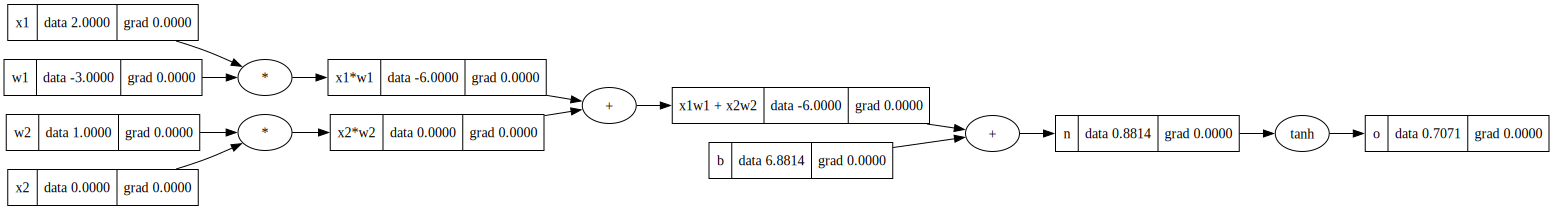

In [59]:
draw_dot(o)

In [55]:
x1.grad = w1.data * x1w1.grad 
w1.grad = x1.data * x1w1.grad
w2.grad = x2.data * x2w2.grad
x2.grad = w2.data * x2w2.grad 

In [52]:
o.grad = 1.0 
# do / dn = 1 - tanh(n) ** 2
n.grad = 1 - o.data ** 2  

x1w1x2w2.grad = 0.5 
bias.grad = 0.5 

x1w1.grad = 0.5
x2w2.grad = 0.5